In [24]:
import pandas as pd


In [25]:
# Load training and test datasets
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")


In [26]:
train_df.head()


,Tweet,Sentiment,Clean_Tweet,Sentiment_3class,Sentiment_Label,tweet_length
0,@roz_avanthay @pinemikey @PierrePoilievre As a...,Strong_Pos,as a 2nd yr student in 1999 he wrote an essay ...,Positive,2,147
1,"Go Canada Truckers, GOoooooo!\nTruckers Freedo...",Strong_Pos,go canada truckers gooooooo truckers freedom c...,Positive,2,103
2,The #FreedomConvoy knew Chris Barber was refer...,Strong_Pos,the knew chris barber was referring to tamara ...,Positive,2,251
3,LIVE CONVOY IN OTTAWA - SATURDAY CANADA EXPOS...,Mild_Neg,live convoy in ottawa saturday canada exposing...,Negative,0,153
4,@PeterDooleyDUB Trudeau said avoid anti-vaxx t...,Strong_Pos,trudeau said avoid antivaxx truckers no one to...,Positive,2,105


In [27]:
test_df.head()


,Tweet,Sentiment,Clean_Tweet,Sentiment_3class,Sentiment_Label,tweet_length
0,Freedom Convoy Canada: Court asked to unfreeze...,Strong_Pos,freedom convoy canada court asked to unfreezeâ...,Positive,2,51
1,Almost $6M in Freedom Convoy money captured as...,Strong_Pos,almost 6m in freedom convoy money captured as ...,Positive,2,81
2,Freedom Convoy-Sounds like J6. Liberals will d...,Strong_Pos,freedom convoysounds like j6 liberals will do ...,Positive,2,231
3,@Ashley06827303 Pls don't paint a whole countr...,Neutral,please dont paint a whole country with such a ...,Neutral,1,230
4,"I don't want to kind of hijack this movement, ...",Strong_Pos,i dont want to kind of hijack this movement bu...,Positive,2,210


In [28]:
X_train = train_df['Clean_Tweet']
y_train = train_df['Sentiment_Label']

X_test = test_df['Clean_Tweet']
y_test = test_df['Sentiment_Label']


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
max_vocab = 10000
max_length = 100  # Adjust based on your data

# Split the data
X = df['Clean_Tweet']             # Text data
y = df['Sentiment_Label']         # Labels

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tokenizer setup
tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_texts)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Now, X_train_pad and X_test_pad are ready for training in a Keras model


NameError: name 'df' is not defined

In [ ]:
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=embedding_dim),  # No input_length
    Bidirectional(GRU(gru_units, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(gru_units)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 3 sentiment classes
])


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint(
    'best_biGRU_model.keras',  # <- new format required
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict classes
y_pred_probs = model.predict(X_test_pad)
y_pred = y_pred_probs.argmax(axis=1)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# AUC
auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovo')
print("AUC:", auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# ---- Predicted labels and probabilities ----
y_pred_probs = model.predict(X_test_pad)  # shape: (n_samples, 3)
y_pred = np.argmax(y_pred_probs, axis=1)

# ---- AUC (macro using One-vs-One) ----
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class='ovo', average='macro')
print(f"AUC Score: {auc_score:.4f}")

# ---- Classification Report ----
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# ---- F1 Scores ----
f1_pos = report['2']['f1-score']
f1_neg = report['0']['f1-score']

# ---- Plot AUC Bar ----
plt.figure(figsize=(6,4))
plt.bar(['AUC'], [auc_score], color='darkorange')
plt.title('AUC Score')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.grid(True)
plt.show()

# ---- Plot F1 Scores ----
plt.figure(figsize=(6,4))
plt.bar(['Negative', 'Positive'], [f1_neg, f1_pos], color=['steelblue', 'seagreen'])
plt.title('F1 Scores for Negative and Positive')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
y_train = y_train.to_numpy()  # If it's still a pandas Series with an index


In [ ]:
y_train = train_df['Sentiment_Label'].values


In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), class_weights))


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_biGRU_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(GRU(128, return_sequences=True, kernel_regularizer=regularizers.l2(0.001))),
    Dropout(0.4),
    Bidirectional(GRU(64, kernel_regularizer=regularizers.l2(0.001))),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])


In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'AUC']
)


In [ ]:
from keras.models import load_model
from keras.preprocessing.sequence import pad_sequences

# Load the model
model = load_model("final_biGRU_model.keras")

# Assume you have your tokenizer already saved/defined
# For example, re-define or load your tokenizer, then prepare input text:
X_test_texts = ["sample test sentence"]

# Convert texts to sequences and pad
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)  # use same maxlen as training

# Predict
predictions = model.predict(X_test_pad)
print(predictions)


In [ ]:
import numpy as np

predicted_class = np.argmax(predictions, axis=1)
print(predicted_class)  # e.g., [1]


In [ ]:
class_labels = ["Negative", "Neutral", "Positive"]
print("Predicted class:", class_labels[predicted_class[0]])


In [ ]:
from keras.preprocessing.sequence import pad_sequences

def preprocess_text(text, tokenizer, max_len=100):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    return padded


In [ ]:
def predict_text(text, model, tokenizer, class_names=['Negative', 'Neutral', 'Positive']):
    processed = preprocess_text(text, tokenizer)
    preds = model.predict(processed)
    predicted_class = class_names[preds.argmax()]
    confidence = preds.max()
    print(f"Input: {text}")
    print(f"Predicted class: {predicted_class} with confidence {confidence:.4f}")


In [ ]:
texts = [
    "I love this product!",
    "It's okay, not great.",
    "I hate it so much."
]

for t in texts:
    predict_text(t, model, tokenizer)


In [ ]:
processed = preprocess_text("This is an example.", tokenizer)
pred_probs = model.predict(processed)
print(pred_probs)  # array with probabilities for each class


In [ ]:
pip install keras-tuner


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize tokenizer and fit on training texts
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_texts)

# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

# Padding
maxlen = 100  # You can adjust this if needed
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)


In [66]:
from tensorflow.keras.models import load_model
best_model = load_model('best_biGRU_model.keras')


In [67]:
model.save('final_biGRU_model.keras')


In [68]:
from tensorflow.keras.models import load_model

model = load_model('final_biGRU_model.keras')


In [39]:
X_train = train_df['Clean_Tweet']
y_train = train_df['Sentiment_Label']

X_test = test_df['Clean_Tweet']
y_test = test_df['Sentiment_Label']

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


ValueError: np.nan is an invalid document, expected byte or unicode string.

In [32]:
#Use Tokenizer to convert tweets to sequences of integers and pad them to the same length:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use cleaned tweets
X_train_texts = train_df['Clean_Tweet'].astype(str)
X_test_texts = test_df['Clean_Tweet'].astype(str)

# Tokenizer setup
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_texts)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

# Pad sequences
max_len = max(len(seq) for seq in X_train_seq)  # or use a fixed value like 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [7]:
#To handle class imbalance without oversampling:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dropout, Dense

inputs = Input(shape=(max_len,))
x = Embedding(input_dim=10000, output_dim=128)(inputs)
x = Bidirectional(GRU(64, return_sequences=True))(x)
x = Dropout(0.5)(x)
x = Bidirectional(GRU(32))(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 80, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 80, 128)             │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 80, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,387,779 (5.29 MB)

 Trainable params: 1,387,779 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Define ModelCheckpoint — use '.keras' extension for full model saving
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# Compile your model (if not compiled already)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Now train the model with callbacks
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node sequential_1/embedding_1_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>

  File "C:\Users\HP\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance

  File "C:\Users\HP\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start

  File "C:\Users\HP\anaconda3\Lib\site-packages\tornado\platform\asyncio.py", line 195, in start

  File "C:\Users\HP\anaconda3\Lib\asyncio\windows_events.py", line 321, in run_forever

  File "C:\Users\HP\anaconda3\Lib\asyncio\base_events.py", line 607, in run_forever

  File "C:\Users\HP\anaconda3\Lib\asyncio\base_events.py", line 1922, in _run_once

  File "C:\Users\HP\anaconda3\Lib\asyncio\events.py", line 80, in _run

  File "C:\Users\HP\anaconda3\Li

In [12]:
from tensorflow.keras.models import load_model

# Load the best model saved during training
best_model = load_model('best_model.keras')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


2315/2315 ━━━━━━━━━━━━━━━━━━━━ 91s 37ms/step - accuracy: 0.8992 - loss: 0.2956
Test Accuracy: 0.8981, Test Loss: 0.2942


In [13]:
# Predict probabilities
y_pred_proba = best_model.predict(X_test_pad)

# Convert to class labels
import numpy as np
y_pred = np.argmax(y_pred_proba, axis=1)

# Compare to true values (optional)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


2315/2315 ━━━━━━━━━━━━━━━━━━━━ 88s 37ms/step
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     13862
           1       0.68      0.82      0.74     11580
           2       0.96      0.95      0.95     48610

    accuracy                           0.90     74052
   macro avg       0.85      0.85      0.85     74052
weighted avg       0.91      0.90      0.90     74052



In [14]:
from sklearn.metrics import f1_score, accuracy_score

# F1 scores for specific classes
f1_positive = f1_score(y_test, y_pred, labels=[2], average='macro')
f1_negative = f1_score(y_test, y_pred, labels=[0], average='macro')

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"F1 Score for Positive (class 2): {f1_positive:.4f}")
print(f"F1 Score for Negative (class 0): {f1_negative:.4f}")
print(f"Accuracy: {accuracy:.4f}")


F1 Score for Positive (class 2): 0.9523
F1 Score for Negative (class 0): 0.8486
Accuracy: 0.8981


2315/2315 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step


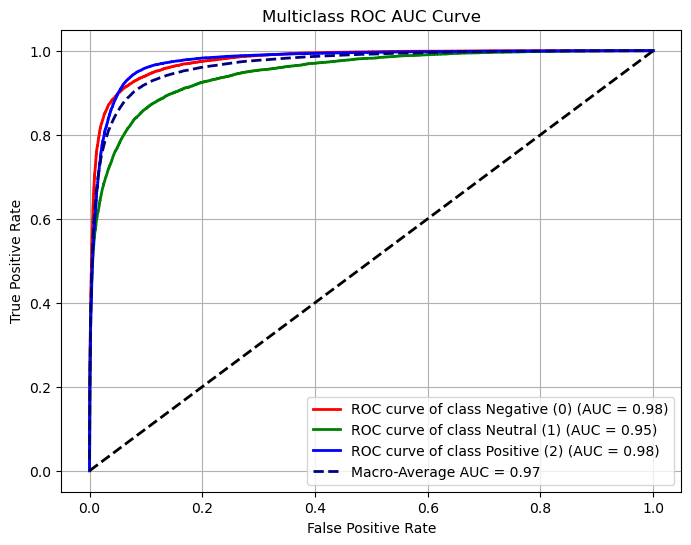

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# One-hot encode true labels and predictions
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_proba = best_model.predict(X_test_pad)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['red', 'green', 'blue'])
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.plot(all_fpr, mean_tpr, color='navy', linestyle='--', label=f"Macro-Average AUC = {macro_auc:.2f}", lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC AUC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [16]:
!pip install googletrans==4.0.0-rc1


In [ ]:
from googletrans import Translator
import random

translator = Translator()

def back_translate(text, lang='fr'):
    try:
        translated = translator.translate(text, dest=lang).text
        back_translated = translator.translate(translated, dest='en').text
        return back_translated
    except:
        return text

# Apply only on class 1 (Neutral or Negative)
augmented_texts = []
augmented_labels = []

for i in range(len(train_df)):
    if train_df['Sentiment_Label'][i] == 1:  # e.g., Neutral
        new_text = back_translate(train_df['Clean_Tweet'][i])
        augmented_texts.append(new_text)
        augmented_labels.append(1)

# Add augmented to original
aug_df = pd.DataFrame({'Clean_Tweet': augmented_texts, 'Sentiment_Label': augmented_labels})
train_df = pd.concat([train_df, aug_df]).reset_index(drop=True)


In [22]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best saved model
best_model = load_model('best_model.keras')

# Predict probabilities on test data
y_pred_proba = best_model.predict(X_test_pad)

# Convert to predicted class labels
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


NameError: name 'X_test_pad' is not defined